#**Tesina Data Spaces**

Author: Andrea Simone Foderaro

Professor: Francesco Vaccarino

A.Y. 2019/2020

# Introduction and Dataset content

Movies always played a big role in everyone's daily life, gathering people together and bringing joy to them. In this paper the CSM (Conventional and Social Media Movies) 2014 and 2015 dataset will be analysed in order to built a predictive model based on the social media and conventional features of a movie. 

The goal is to predict the Gross Income based on the features.

The dataset, downloadable for free [here](https://archive.ics.uci.edu/ml/datasets/CSM+%28Conventional+and+Social+Media+Movies%29+Dataset+2014+and+2015), contains 231 istances with 14 attributes and it was donated the 11th of October by Mehreen Ahmed.

To analyse the set Python will be used due to practical reasons, Colab do not support R.

In [0]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.decomposition import PCA
from sklearn.metrics import plot_confusion_matrix

from sklearn import svm
from sklearn.linear_model import LogisticRegression

from matplotlib import pyplot as plt

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


The libraries used are:

* [Pandas](https://pandas.pydata.org/pandas-docs/stable/index.html): library providing high-performance, easy-to-use data structures and data analysis tools for the Python programming language

* [NumPy](https://numpy.org/): fundamental package for scientific computing with Python

* [Seaborn](https://seaborn.pydata.org/): Python data visualisation library based on matplotlib

* [Scikit-learn](https://scikit-learn.org/stable/index.html): simple and efficient tools for predictive data analysis

* [Matplotlib](https://matplotlib.org/): comprehensive library for creating static, animated and interactive visualisations in Python

# Data Exploration

The dataset is composed of 231 istances, each of them has 14 colums: where *Sentiment*, *Comments*, *Likes*, *Dislikes* and *Aggregate Followers* are social media features while the others are conventional features. Some of the attributes values are missing, especially in the *Aggregate Followers* attribute.

Here are some basic informations about the data:

In [0]:
# Read the dataset from the csv file
dataset = pd.read_csv('dataset.csv', sep=';', decimal=',')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231 entries, 0 to 230
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Movie                231 non-null    object 
 1   Year                 231 non-null    int64  
 2   Ratings              231 non-null    float64
 3   Genre                231 non-null    int64  
 4   Gross                231 non-null    int64  
 5   Budget               230 non-null    float64
 6   Screens              221 non-null    float64
 7   Sequel               231 non-null    int64  
 8   Sentiment            231 non-null    int64  
 9   Views                231 non-null    int64  
 10  Likes                231 non-null    int64  
 11  Dislikes             231 non-null    int64  
 12  Comments             231 non-null    int64  
 13  Aggregate Followers  196 non-null    float64
dtypes: float64(4), int64(9), object(1)
memory usage: 25.4+ KB


As stated from the output above, *Budget*, *Screens* and *Aggregate Followers* have missing values. Different approaches may be used to handle this problem: delete the row or the column with missing values, back-fill or forward-fill to propagate next or previous values respectively or use a global costant to fill the missing values.

Since it is just one row, the one with the *Budget* missing value can be deleted. For the same reason also the rows with null *Screens* values can be deleted. On the other hand, the *Aggregate Followers* column has too many missing values, deleting the rows would influence too much on the analysis and that's why the column will be dropped.

Moreover, also the *Movie* and the *Year* columns have been dropped, since the name of a movie and the year are not attributes that can be used in an analysis, ie. they are not useful.

In [0]:
# reading from data set only the interesting columns
df = dataset[['Genre', 'Budget', 'Screens', 'Sequel', 'Sentiment', 
         'Views', 'Likes', 'Dislikes', 'Comments', 'Ratings', 'Gross']]

# dropping the rows with null attributes values
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 220 entries, 0 to 230
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Genre      220 non-null    int64  
 1   Budget     220 non-null    float64
 2   Screens    220 non-null    float64
 3   Sequel     220 non-null    int64  
 4   Sentiment  220 non-null    int64  
 5   Views      220 non-null    int64  
 6   Likes      220 non-null    int64  
 7   Dislikes   220 non-null    int64  
 8   Comments   220 non-null    int64  
 9   Ratings    220 non-null    float64
 10  Gross      220 non-null    int64  
dtypes: float64(3), int64(8)
memory usage: 20.6 KB


Here it is possible to see the new informations on the data after some pre-processing: 220 istances, with 11 features, *Gross* will be used as label for the analysis.

Example of dataset row content:

In [0]:
df.head()

,Genre,Budget,Screens,Sequel,Sentiment,Views,Likes,Dislikes,Comments,Ratings,Gross
0,8,4000000.0,45.0,1,0,3280543,4632,425,636,6.3,9130
1,1,50000000.0,3306.0,2,2,583289,3465,61,186,7.1,192000000
2,1,28000000.0,2872.0,1,0,304861,328,34,47,6.2,30700000
3,1,110000000.0,3470.0,2,0,452917,2429,132,590,6.3,106000000
4,8,3500000.0,2310.0,2,0,3145573,12163,610,1082,4.7,17300000


Here are the main statistical values of the different features. 

In [0]:
df.describe()

,Genre,Budget,Screens,Sequel,Sentiment,Views,Likes,Dislikes,Comments,Ratings,Gross
count,220.000000,2.200000e+02,220.000000,220.000000,220.000000,2.200000e+02,220.000000,220.000000,220.000000,220.000000,2.200000e+02
mean,5.395455,4.961817e+07,2217.322727,1.377273,2.890909,3.815970e+06,12348.022727,689.863636,1773.968182,6.471818,7.113309e+07
std,4.187716,5.474385e+07,1462.159806,0.987794,7.130673,4.555839e+06,26965.513051,1256.845504,3283.754798,0.981578,8.994169e+07
min,1.000000,7.000000e+04,2.000000,1.000000,-38.000000,6.980000e+02,1.000000,0.000000,0.000000,3.100000,2.470000e+03
25%,1.000000,1.100000e+07,458.000000,1.000000,0.000000,6.897918e+05,2171.250000,121.750000,284.000000,5.900000,1.290000e+07
50%,3.000000,2.850000e+07,2777.500000,1.000000,0.500000,2.550080e+06,6561.500000,365.500000,876.000000,6.500000,4.060000e+07
75%,8.000000,6.500000e+07,3373.000000,1.000000,6.000000,5.219400e+06,15383.000000,704.750000,2176.250000,7.100000,9.117500e+07
max,15.000000,2.500000e+08,4324.000000,7.000000,29.000000,3.262678e+07,370552.000000,13960.000000,38363.000000,8.700000,6.430000e+08


Since *Genre* is a categorical attribute, it has to be treated carefully, ie. an encoding of the variable is required. Two alternatives can be applied: One Hot Encoding or Binary Encoding. 

One Hot Encoding consists of substituiting the categorical feature into *n* columns, where *n* is the number of distinct values of the attribute, and put 1 only in the value of the column related to that category, all the other columns are put to 0. On the other hand, Binary Encoding uses *k* columns to represent each category as a binary number, where *k* is the minimum number of bits to be able to represent the maximum value of the attribute.

Here Binary Encoding is used, introducing 4 columns, since *Genre* is a number from 1 to 15. The columns introduced are: *Genre_3*, *Genre_2*, *Genre_1*, *Genre_0*, where the last is the Least Significant Bit.

In [0]:
# Binary encoding of Genre
g0 = []
g1 = []
g2 = []
g3 = []

for genre in df["Genre"]:
  genre_encoded = '{0:04b}'.format(genre)
  
  g0.append(genre_encoded[3])
  g1.append(genre_encoded[2])
  g2.append(genre_encoded[1])
  g3.append(genre_encoded[0])

df['Genre_3'] = g3
df['Genre_2'] = g2
df['Genre_1'] = g1
df['Genre_0'] = g0

df1 = df[['Budget', 'Screens', 'Sequel', 'Sentiment', 'Views', 'Likes', 
         'Dislikes', 'Comments', 'Ratings', 'Genre_3', 'Genre_2', 'Genre_1', 
         'Genre_0', 'Gross']]

As the output of the statical values shows, the different features have very different scales. This means that a normalisation or standardisation of the data has to be performed. 

In this paper a Normalisation has been performed, ie. rescale the values to be into a range of [0, 1]. In order to do that, the minimum value of the column is subtracted to the attribute's value and the resulted number is then divided by the difference between the maximum and minimum value of the feature, following this formula:

> $ x^{k}_{i} = \frac{x^{k}_{i} - x^{k}_{min}}{x^{k}_{max} - x^{k}_{min}}$

where $x^{k}_{i}$ is the value of the $k^{th}$ feature of the $i^{th}$ sample, $x^{k}_{max}$ and $x^{k}_{min}$ are respectively the maximum and minimum values of the $k^{th}$ feature. 

The cost of having this bounded range is that we will end up with smaller standard deviations, which can suppress the effects of outliers.

In [0]:
# Normalisation of the data
scaler = MinMaxScaler()

scaled_df = scaler.fit_transform(df1)
df1 = pd.DataFrame(scaled_df, columns=df1.columns)

df1.describe()

,Budget,Screens,Sequel,Sentiment,Views,Likes,Dislikes,Comments,Ratings,Genre_3,Genre_2,Genre_1,Genre_0,Gross
count,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000
mean,0.198248,0.512569,0.062879,0.610312,0.116939,0.033321,0.049417,0.046242,0.602110,0.445455,0.127273,0.368182,0.586364,0.110623
std,0.219037,0.338306,0.164632,0.106428,0.139638,0.072771,0.090032,0.085597,0.175282,0.498149,0.334038,0.483411,0.493608,0.139879
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.043732,0.105507,0.000000,0.567164,0.021121,0.005857,0.008721,0.007403,0.500000,0.000000,0.000000,0.000000,0.000000,0.020058
50%,0.113752,0.642180,0.000000,0.574627,0.078139,0.017705,0.026182,0.022835,0.607143,0.000000,0.000000,0.000000,1.000000,0.063138
75%,0.259793,0.779963,0.000000,0.656716,0.159955,0.041511,0.050484,0.056728,0.714286,1.000000,0.000000,1.000000,1.000000,0.141793
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Now all the features have min = 0, max = 1 and low standard deviation.

In [0]:
# Division of training and test sets
y = df1[['Gross']]
ds = df1[['Budget', 'Screens', 'Sequel', 'Sentiment', 
         'Views', 'Likes', 'Dislikes', 'Comments', 'Ratings', 
         'Genre_3', 'Genre_2', 'Genre_1', 'Genre_0']]

In order to see if there is any correlation between any two attributes, the correlation matrix was computed. The correlation between two features measures both the strength and direction of the linear relationship between the two variables.

A *Correlation Matrix* is a table showing correlation coefficients between variable, ie. each cell in the table shows how much correlation there is between two variables. 

Here the Pearson's correlation coefficients has been used, because the data in analysis is quantitative, this means that the values in the matrix will be between -1 and 1. The coefficients are computed following the formula:

> $C_{x_i,x_j} = \frac{Cov(x_i,x_j)}{\sigma_{x_i}\sigma_{x_j}}$

where $Cov(x_i, x_j)$ is the covariance between $x_i$ and $x_j$ and $\sigma_{x_i}$ is the standard deviation of $x_i$. The matrix will be symmetric since $Cov(x_i, x_j) = Cov(x_j, x_i)$

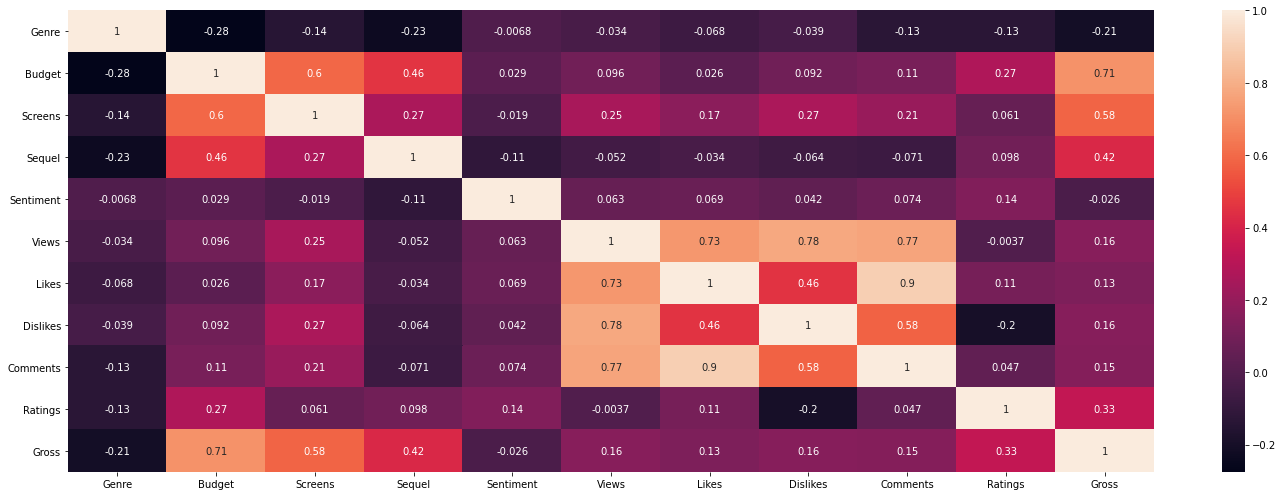

In [0]:
# Correlation Matrix
f, axes = plt.subplots(figsize=(20, 7))

sns.heatmap(df.corr(), annot=True, fmt='.2g', ax=axes)
plt.tight_layout()

From the matrix we can read which are the attributes that are related to each other, lighter is the color of the background of the cell the more the two variables are correlated. 

As predicted, the matix is a symmetric matrix and the more related features are: *Budget* and *Screens*, *Views* and *Likes*, *Views* and *Dislikes*, *Views* and *Comments* and *Likes* and *Comments*. More interesting is the correlation between the output label *Gross* and the features *Budget* and *Screens*.

# Data Analyses

Since there's no test set, a partition on the dataset has been made. The partition is 70% training and 30% test set, the samples has been chosen randomly.

In [0]:
# Split test and training set
X_train, X_test, y_train, y_test = train_test_split(ds, y, test_size=0.3, random_state=42)

## Method 1: Linear Regression

As first method, Linear Regression has been run on the training set to predict *Gross*.

Regression is used since the dependent variable *Gross* is not discrete. 

Linear Regression attempts to model the relationship between two variables by fitting a linear equation to observed data. One variable is called predictor or independent variable and the other is the response or dependent variable. The main idea is to find the line that best fits the training data.

Linear Regression assumes that the dependence of $Y$ on $X_1, X_2, ..., X_p$ is linear, where $p$ is the number of features. The model is:

> $Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + ... + \beta_pX_p + \epsilon$

where $\beta_i$ are unkown constants, also known as coefficients or parameters, and $\epsilon$ is the error term.

The best line is the one for which the total prediction error is as small as possible. The prediction error is defined as the Residual Sum of Squares. Given the found coefficients $\hat{\beta}_i$ we can make prediction using the formula:

> $\hat{y} = \hat{\beta}_0 + \hat{\beta}_1x_1 + \hat{\beta}_2x_2 + ... + \hat{\beta}_px_p$

and then RSS will be defined as:

> $RSS = \sum_{i=1}^{n}{(y_i - \hat{y}_i)^2}$

where $n$ is the number of samples in the dataset, $y_i$ is the actual output value and $\hat{y}_i$ is the value predicted by the model. The algorithm selects $\hat{\beta}_i$ in order to minimize $RSS$.

In [0]:
# Gross Linear Regression
reg = LinearRegression().fit(X_train, y_train)
reg.score(X_test, y_test)

0.5422960998549425

The precision of the Linear Regression is slightly above 54%, not good. This is probably because we are using all the features for the predicition, where some of them are strongly uncorrelated to the output label.

## Method 2: Random Forest

Tree based methods for regression and classification involve stratifying or segmenting the predictor space into a number of simple regions. Since the set of splitting rules used to segment the predictor space can be summarised in a tree, these types of approaches are known as *decision-tree* methods.

Overall, the tree stratifies or segments the data into regions of predictor space. The splitting is done until all the features have been exploited or a terminal node with certain characteristics is reached. The terminal nodes are also called leaves.

The predictor space - that is the set of possible values for $X_1, X_2, \cdot\cdot\cdot, X_p$ - is divided into $J$ distinct and non-overlapping regions, $R_1, R_2,..., R_J$. For every observation that falls into the region $R_j$, we make the same prediction, which is simply the mean of the response values for the training observations in $R_j$.

The goal is to find regions $R_1, R_2, ..., R_J$ that minimize the RSS, given by:

> $RSS = \sum_{j=1}^{J}\sum_{i\in R_j}{(y_i - \hat{y}_{R_j})^2}$

where $\hat{y}_{R_j}$ is the mean response for the training observations within the $j$th region.

The approach is top-down greedy because it begins at the top of the tree and then iteratively splits the predictor space; each split is indicated via two new branches further down on the tree. 

We predict the response for a given test observation using the mean of the training observations in the region to which that test observation belongs.

Random Forest builts $n$ decision trees and it averages the results of the trees to make predictions. In building the trees, at each split, a random selection of $m$ predictors is chosen as split candidates from the full set of $p$ predictors. The split is allowed to use only one of those $m$ predictors. A fresh selection of $m$ predictors is taken at each split, and typically $m \approx \sqrt{p}$. 

In [0]:
# Random Forest Regressor for Gross
rfreg = RandomForestRegressor(max_depth=4, random_state=42).fit(X_train, y_train['Gross'])
rfreg.score(X_test, y_test)

0.738895205170484

The Random Forest has higher accuracy, 73,8%. This result is probably due to the fact that the algorithm averages the results of more than one model, where each model is built only focusing on a subset of the features. Overall at the end the prediction will be based on the more important features.

# Alternative Method: PCA

Here the same methods applied before are used again, but after the application of the PCA.

The idea of PCA, Principal Component Analysis, is to represent the dataset into a smaller space. The goal is to find the principal components of the features and use a subset of them, the most important ones. In simpler words it means to seek the most accurate data representation in a lower dimensional space. 

The principal components are linear combinations of the predictors. The first principal component is the (normalized) linear combination of the features with the largest variance. The following principal components have the same constraint and, in addition, they have to be uncorrelated to the previuosly computed ones, ie. their dot product must be equal to 0. 

Hence with many correlated original attributes, like in this case, a small set of principal components that campture their joint variation replaces them.

The number of components was selected to yield at least 90% of the original standard deviation.

In [0]:
# PCA
n_c = 0
for i in range(1, 11):
  pca = PCA(n_components=i).fit(ds)
  if sum(pca.explained_variance_ratio_) > 0.9:
    n_c = i
    break
print(n_c)

pca = PCA(n_components=n_c).fit_transform(ds)

6


Using PCA it results that we only need 6 features instead of 10, loosing only 10% of the original standard deviation.

In [0]:
pca_train, pca_test, pca_y_train, pca_y_test = train_test_split(pca, y, test_size=0.3, random_state=42)

Linear Regression with PCA

In [0]:
# Linear Regression with PCA
pca_reg = LinearRegression().fit(pca_train, pca_y_train)
pca_reg.score(pca_test, pca_y_test)

0.5888250613882017

Random Forest with PCA

In [0]:
# Random Forest with PCA
rf_pca = RandomForestRegressor(max_depth=4, random_state=42).fit(pca_train, pca_y_train['Gross'])
rf_pca.score(pca_test, pca_y_test)

0.644521862258822

The only increase in accuracy is in Linear Regression, from 54% to 59%, while Random Forest performance decreases from 74% to 64%.

This results can be connected to the previuos conclusions. In Linear Regression the accuracy is lower with no PCA probably because features that are not relevant are used in the analysis. On the other hand, Random Forest already avoids that problem thanks to the use of multiple models, this is why the accuracy decreases using PCA.

# Alternative Analysis

Another analysis can be performed on the Net Income.

The Net Income can be computed as *Gross* - *Budget*. A new variable is introduced: *Net*.

In [0]:
df2 = df[['Budget', 'Screens', 'Sequel', 'Sentiment', 
          'Views', 'Likes', 'Dislikes', 'Comments', 'Ratings', 
          'Genre_3', 'Genre_2', 'Genre_1', 'Genre_0', 'Gross']]

df2['Net'] = df2['Gross'] - df2['Budget']

df2 = df2[['Budget', 'Screens', 'Sequel', 'Sentiment', 
           'Views', 'Likes', 'Dislikes', 'Comments', 'Ratings', 
           'Genre_3', 'Genre_2', 'Genre_1', 'Genre_0', 'Net']]

This new feature, as all the others, has to be normalised as before.

In [0]:
# Normalise data
scaled_df = scaler.fit_transform(df2)

df2 = pd.DataFrame(scaled_df, columns=df2.columns)
df2.describe()

,Budget,Screens,Sequel,Sentiment,Views,Likes,Dislikes,Comments,Ratings,Genre_3,Genre_2,Genre_1,Genre_0,Net
count,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000
mean,0.198248,0.512569,0.062879,0.610312,0.116939,0.033321,0.049417,0.046242,0.602110,0.445455,0.127273,0.368182,0.586364,0.241498
std,0.219037,0.338306,0.164632,0.106428,0.139638,0.072771,0.090032,0.085597,0.175282,0.498149,0.334038,0.483411,0.493608,0.102521
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.043732,0.105507,0.000000,0.567164,0.021121,0.005857,0.008721,0.007403,0.500000,0.000000,0.000000,0.000000,0.000000,0.198291
50%,0.113752,0.642180,0.000000,0.574627,0.078139,0.017705,0.026182,0.022835,0.607143,0.000000,0.000000,0.000000,1.000000,0.220882
75%,0.259793,0.779963,0.000000,0.656716,0.159955,0.041511,0.050484,0.056728,0.714286,1.000000,0.000000,1.000000,1.000000,0.269627
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Two classes were created using the percentiles. Class 0 is refered to the 50%, Class 1 to the rest.

In [0]:
# Label encoding
labels = []

p = df2['Net'].quantile(0.5)
for value in df2['Net']:
  if (value > p):
    labels.append(1)
  else:
    labels.append(0)

df2['Net_label'] = labels

df2 = df2[['Budget', 'Screens', 'Sequel', 'Sentiment', 
           'Views', 'Likes', 'Dislikes', 'Comments', 'Ratings', 
           'Genre_3', 'Genre_2', 'Genre_1', 'Genre_0', 'Net_label']]

Split in train and test sets.

In [0]:
y = df2['Net_label']
ds2 = df2[['Budget', 'Screens', 'Sequel', 'Sentiment', 
           'Views', 'Likes', 'Dislikes', 'Comments', 'Ratings', 
           'Genre_3', 'Genre_2', 'Genre_1', 'Genre_0']]

X_train, X_test, y_train, y_test = train_test_split(ds2, y, test_size=0.3, random_state=42)

## Method 1: SVM

SVM is a linear model for classification and regression problems. The idea of this algorithm is simple: find the line or hyperplane which best separates the classes.

SVM, in order to find the best separating line or hyperplane, first finds the points closest to the line or hyperplane for both classes, these points are called *support vectors*. Now the distance of the support vectors and the line or hyperplane is computed. The best line or the hyperplane is the one for which the distance, also called margin, is maximised.

In formula:

> $\max\limits_{w,b} \frac{1}{||w||} \space {subject} \space {to} \space  y_i [<x_i,w> + b] \geq 1$

where $w$ is the vector perpendicular to the hyperplane or line, $b$ is the bias term, $||w||$ is the norm of $w$ and the equation $y_i [<x_i,w> + b] \geq 1$ represents the fact that the SVM has to correctly classify every point $x_i$ with label $y_i$.

In [0]:
svm_clf = svm.SVC().fit(X_train, y_train)
svm_clf.score(X_test, y_test)

0.6212121212121212

62% accuracy is not very good, ie. the two classes are not perfectly separable. The error here can be probably related to the fact that some of the movies have a high net income despite a low initial investement.

## Method 2: Logistic Regression

Logistic Regression is a machine learning algorithm that, as stated by the name, uses a logistic function in order to perform a binary classification. The formula of the logistic function is this one:

> $f(x) = \frac{1}{1+e^{-x}}$

and the value of $f$ are bounded between [0, 1].

However the Logistic Regression algorithm actually uses this formula for predicting the $y$ label of a record:

> $y = \frac{e^{\beta_0 + \beta_1X}}{1 + e^{\beta_0 + \beta_1X}}$

where $\beta_0$ and $\beta_1$ are the weights coefficients trained by the algorithm. The maximum likelehood is used to compute these parameters. The likelihood gives the probability of the observed zeros and ones in the data. The best $\beta_0$ and $\beta_1$ are the ones that maximise the likelihood of the observed data.

In [0]:
log_clf = LogisticRegression(random_state=42).fit(X_train, y_train)
log_clf.score(X_test, y_test)

0.6363636363636364

Again here, as for the SVM, the accuracy is low, 63%, probably for the fact that the two classes are not separable, due to the presence of those outliers.

# Conclusions


As the first analysis pointed out, the maximum accuracy achievable is around 74%, maintaing the models relatively simple.

Moreover the maximum accuracy is achieved by the Random Forest algorithm, using the entire set of features. Meanwhile, applying a feature reduction usign PCA increases only the Linear Regression accuracy. This is probably because some of the features are irrelevant for the analysis, ie. the small numbers in the *Gross* row of the correlation matrix.

In the end, the accuracy achieved is relatively low, 70% is not a good result. This is probably due to dimension of the dataset, which is not big enough to provide a better analysis.

For what it concerns the second analysis, the accuracy of both algorithms is around 62-63%. Again not a very good result, probably for the reasons stated before, ie. the two classes are not separable. 

In conclusion, in both the analyses is clear that the Income, Gross or Net, can be predicted usign the relevant features presented in the dataset, but in both cases the predecition will have a not negligible error.

# References


- Ahmed M, Jahangir M, Afzal H, Majeed A, Siddiqi I. Using Crowd-source based features from social media and Conventional features to predict the movies popularity. InSmart City/SocialCom/SustainCom (SmartCity), 2015 IEEE International Conference on 2015 Dec 19 (pp. 273-278). IEEE

- [Scikit-learn: Machine Learning in Python](http://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html), Pedregosa *et al.*, JMLR 12, pp. 2825-2830, 2011

- Wes McKinney. Data Structures for Statistical Computing in Python, Proceedings of the 9th Python in Science Conference, 51-56 (2010), [link](http://conference.scipy.org/proceedings/scipy2010/mckinney.html)

- John D. Hunter. Matplotlib: A 2D Graphics Environment, Computing in Science & Engineering, 9, 90-95 (2007), [link](https://aip.scitation.org/doi/abs/10.1109/MCSE.2007.55)

- Travis E. Oliphant. A guide to NumPy, USA: Trelgol Publishing, (2006)

- Stéfan van der Walt, S. Chris Colbert and Gaël Varoquaux. The NumPy Array: A Structure for Efficient Numerical Computation, Computing in Science & Engineering, 13, 22-30 (2011), [link](https://aip.scitation.org/doi/abs/10.1109/MCSE.2011.37)